In [1]:

import os
import base64
from datetime import datetime
from typing import TypedDict, Optional
from langgraph.graph import StateGraph, END
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage
from openai import OpenAI
import torch
import torch.nn.functional as F
from PIL import Image
from transformers import AutoImageProcessor, AutoModel

# ----------------------------------------------------------------------
# 0) chat model / image client setting
# ----------------------------------------------------------------------
llm = init_chat_model(model = "openai:gpt-5-nano")   # 평가 판정 + reanchor 진단(비전)
client = OpenAI()                                    # 이미지 생성/편집 (gpt-image-2)

ASSET_DIR = "./assets"                               # 생성 이미지 저장 루트 (실행별 timestamp 하위 폴더)
IMAGE_MODEL = "gpt-image-2"

# ----------------------------------------------------------------------
# 1) 임베딩 모델 로딩 (프로세스당 한 번만 — 모듈 import 시점에 1회 로드)
# ----------------------------------------------------------------------
_MODEL_NAME = "facebook/dinov2-base"   # 나중에 dinov3로 드롭인 교체 가능
_device = "cuda" if torch.cuda.is_available() else "cpu"
 
_processor = AutoImageProcessor.from_pretrained(_MODEL_NAME)
_model = AutoModel.from_pretrained(_MODEL_NAME).to(_device).eval()

/Users/xiwoo/project/study/ai-agent-task/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 223/223 [00:00<00:00, 6183.14it/s]


In [2]:

@torch.no_grad()
def embed(image_path: str) -> torch.Tensor:
    """이미지 1장 -> 정규화된 임베딩 벡터(1, D)."""
    img = Image.open(image_path).convert("RGB")
    inputs = _processor(images=img, return_tensors="pt").to(_device)
    out = _model(**inputs)
    # DINOv2의 전역 표현 = CLS 토큰 (last_hidden_state[:, 0])
    cls = out.last_hidden_state[:, 0]
    return F.normalize(cls, dim=-1)
 
 
def cosine_consistency(path_a: str, path_b: str) -> float:
    """두 이미지의 코사인 유사도 (정규화 벡터이므로 내적과 동일). 보통 0~1."""
    a, b = embed(path_a), embed(path_b)
    return F.cosine_similarity(a, b).item()

In [3]:

# ----------------------------------------------------------------------
# 2) LangGraph 상태 정의
# ----------------------------------------------------------------------
class AgentState(TypedDict):
    prompt: str                    # 최초 생성 프롬프트
    edit_instruction: str          # 사용자의 수정 지시 (변경분 delta)
    run_dir: str                   # 이번 실행의 timestamp 폴더 (모든 이미지가 여기 저장됨)
    canonical_path: str            # 비교 기준: 원본 A 또는 최신 확정본
    candidate_path: str            # 방금 만든 후보 B
    consistency: Optional[float]   # 이번 후보의 일관성 점수
    retry_count: int               # 재시도 횟수 (무한 루프 방지)
    verdict: Optional[str]         # generate_initial의 평가 판정: "accept" | "edit"


# 튜닝 대상 — 아래 NOTE 참고. 시작값일 뿐 실측으로 보정할 것.
CONSISTENCY_THRESHOLD = 0.85
MAX_RETRIES = 3

In [4]:
# ----------------------------------------------------------------------
# 3) 헬퍼
# ----------------------------------------------------------------------
def _save_b64_png(b64: str, path: str) -> str:
    """gpt-image-2 응답(b64_json)을 PNG 파일로 저장하고 경로를 반환."""
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "wb") as f:
        f.write(base64.b64decode(b64))
    return path


def _b64_of(path: str) -> str:
    """로컬 이미지 파일을 base64 문자열로 인코딩 (LLM 비전 입력용)."""
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode()


def _show(path: str, caption: str = "", width: int = 320) -> None:
    """노트북에서 이미지 미리보기. width 는 '출력 렌더링 크기'만 조절(저장 파일엔 영향 없음).
    IPython이 없으면 경로만 출력."""
    if caption:
        print(caption)
    try:
        from IPython.display import Image as IPyImage, display
        display(IPyImage(filename=path, width=width))
    except Exception:
        print(f"  -> {path}")


# ----------------------------------------------------------------------
# 4) 분기 함수
# ----------------------------------------------------------------------
def route_after_initial(state: AgentState) -> str:
    """generate_initial의 평가 판정으로 다음 경로 결정 (conditional edge용).
    노드는 스스로 END로 갈 수 없으므로 분기는 여기서 처리한다."""
    if state["verdict"] == "accept":
        return "__end__"
    return "edit_image"


def route_after_scoring(state: AgentState) -> str:
    """임계값과 재시도 횟수로 다음 경로를 결정 (conditional edge용)."""
    if state["consistency"] >= CONSISTENCY_THRESHOLD:
        return "accept"
    if state.get("retry_count", 0) >= MAX_RETRIES:
        # 계속 실패하면 무한 루프 대신 종료 (사용자 확인 단계로 확장 가능)
        return "__end__"
    return "reanchor"


# ----------------------------------------------------------------------
# 5) 생성/편집 노드
# ----------------------------------------------------------------------
def generate_initial(state: AgentState) -> dict:
    """
        텍스트 -> 이미지 A 생성 후 사용자 평가를 받아 분기.
        1. gpt-image-2 로 프롬프트 기반 이미지 A 생성
        2. 생성 시점 timestamp 로 실행 폴더(run_dir)를 만들고 canonical.png 저장
        3. 이미지를 출력(사용자 확인용)
        4. input() 으로 사용자 평가 입력 받기
        5. 평가를 llm 에 전달해 accept/edit 판정 + (edit 시) 수정 지시문 추출
        6. 긍정 평가 -> verdict="accept" (route_after_initial 가 END 로 보냄)
        7. 수정 요청 -> verdict="edit" (route_after_initial 가 edit_image 로 보냄)
        8. run_dir / canonical_path / edit_instruction 저장
    """
    # 첫 이미지가 생성되는 순간의 timestamp 로 실행 폴더 구성 (이후 candidate 도 여기에 저장)
    run_dir = f"{ASSET_DIR}/{datetime.now().strftime('%Y%m%d_%H%M%S')}"

    resp = client.images.generate(model=IMAGE_MODEL, prompt=state["prompt"])
    canonical_path = _save_b64_png(resp.data[0].b64_json, f"{run_dir}/canonical.png")
    _show(canonical_path, "생성된 초기 이미지 A:")

    feedback = input("이 이미지에 대한 평가를 입력하세요 (만족하면 그대로, 수정 원하면 어떻게 바꿀지): ")

    judge_prompt = (
        "사용자가 방금 생성된 이미지를 다음과 같이 평가했다:\n"
        f'"{feedback}"\n\n'
        "이 평가가 이미지에 만족(확정)하는 긍정적 평가인지, 수정을 원하는지 판단하라.\n"
        "- 만족하면 첫 줄에 정확히 ACCEPT 만 출력.\n"
        "- 수정을 원하면 첫 줄에 정확히 EDIT 를 출력하고, 둘째 줄부터 "
        "이미지 편집 모델에 전달할 간결한 수정 지시문을 한국어로 작성하라."
    )
    decision = llm.invoke(judge_prompt).content.strip()
    first, _, rest = decision.partition("\n")

    if first.strip().upper().startswith("ACCEPT"):
        return {"run_dir": run_dir, "canonical_path": canonical_path, "verdict": "accept"}

    edit_instruction = rest.strip() or feedback
    return {
        "run_dir": run_dir,
        "canonical_path": canonical_path,
        "edit_instruction": edit_instruction,
        "verdict": "edit",
    }


def edit_image(state: AgentState) -> dict:
    """
        canonical_path 이미지 + edit_instruction -> 후보 B 생성.
        1. canonical_path 이미지를 가져옴
        2. edit_instruction 과 함께 이미지 편집 모델에 재생성 요청
        3. 후보 B 를 같은 run_dir 에 저장 (파일명 뒤에 retry_count 인덱싱)
        4. 생성 경로를 candidate_path 로 저장
        (재시도 카운터는 reanchor 에서만 +1 한다)
    """
    with open(state["canonical_path"], "rb") as img:
        resp = client.images.edit(
            model=IMAGE_MODEL,
            image=img,
            prompt=state["edit_instruction"],
        )
    candidate_path = _save_b64_png(
        resp.data[0].b64_json,
        f"{state['run_dir']}/candidate_{state.get('retry_count', 0)}.png",
    )
    return {"candidate_path": candidate_path}


def score_consistency(state: AgentState) -> dict:
    """
        후보 B와 캐노니컬 이미지의 일관성을 계산해 상태에 기록.
    """
    score = cosine_consistency(state["canonical_path"], state["candidate_path"])
    print(f"[score] consistency = {score:.4f} (threshold {CONSISTENCY_THRESHOLD})")
    return {"consistency": score}


def accept(state: AgentState) -> dict:
    """
        후보를 확정 -> 재시도 카운터 초기화
        1. 확정된 이미지에 대한 사용자 확인용 출력
        2. retry_count 초기화
    """
    _show(state["candidate_path"], "확정된 이미지:")
    return {"retry_count": 0}


def reanchor(state: AgentState) -> dict:
    """
        드리프트 누적 시 원본 A 기준으로 다시 편집하도록 보강.
        1. retry_count +1
        2. (Optional) canonical/candidate 이미지 + edit_instruction 을 LLM 에 보내
           불일치 원인을 묻고, 보강 지시문을 받아 edit_instruction 에 덧붙임.
    """
    msg = HumanMessage(content=[
        {
					"type": "text",
					"text": f"""
						아래 두 이미지는 같은 에셋의 원본(A)과 편집 후보(B)다. 
						B 가 A 와 시각적 일관성이 부족하다.

						원본 이미지 생성 요청 지시: {state["prompt"]}
						수정 지시: {state['edit_instruction']}

						두 이미지는 불일치 할 수 있지만, 원본 이미지 생성 요청 지시에 맞추면서 수정 지시에 맞추며 일관성은 유지되어야 한다.
						일관성을 높이기 위해 '추가로 더할' 간결한 보강 지시문만 한국어로 출력하라.
						
						<IMPORTANT>
							- 수정 지시를 무시하는 보강 지시문을 생성하지 말고, 유지하는 방향에서 일관성을 높이는 지시문을 생성할 것
						</IMPORTANT>
					""",
        },
        {"type": "image", "base64": _b64_of(state["canonical_path"]), "mime_type": "image/png"},
        {"type": "image", "base64": _b64_of(state["candidate_path"]), "mime_type": "image/png"},
    ])
    extra = llm.invoke([msg]).content.strip()
    print(f"[reanchor] 보강 지시문 추가:\n{extra}")
    return {
        "edit_instruction": state["edit_instruction"] + "\n" + extra,
        "retry_count": state.get("retry_count", 0) + 1,
    }

In [5]:

# ----------------------------------------------------------------------
# 6) 그래프 배선 (생성 -> [분기] -> 편집 -> 점수 -> 분기)
# ----------------------------------------------------------------------

graph_builder = StateGraph(AgentState)

(
  graph_builder
  .add_node("generate_initial", generate_initial)
  .add_node("edit_image", edit_image)
  .add_node("score_consistency", score_consistency)
  .add_node("accept", accept)
  .add_node("reanchor", reanchor)
)

(
  graph_builder
  .set_entry_point("generate_initial")
  # generate_initial 은 노드 안에서 END/edit 를 못 정하므로 conditional edge 로 분기
  .add_conditional_edges(
    "generate_initial",
    route_after_initial,
    ["edit_image", "__end__"]
  )
  .add_edge("edit_image", "score_consistency")
  .add_conditional_edges(
    "score_consistency",
    route_after_scoring,
    ["accept", "reanchor", "__end__"]
  )
  .add_edge("accept", END)
  .add_edge("reanchor", "edit_image")
)

# input() 기반 human-in-the-loop 이라 checkpointer 불필요
graph = graph_builder.compile()

생성된 초기 이미지 A:


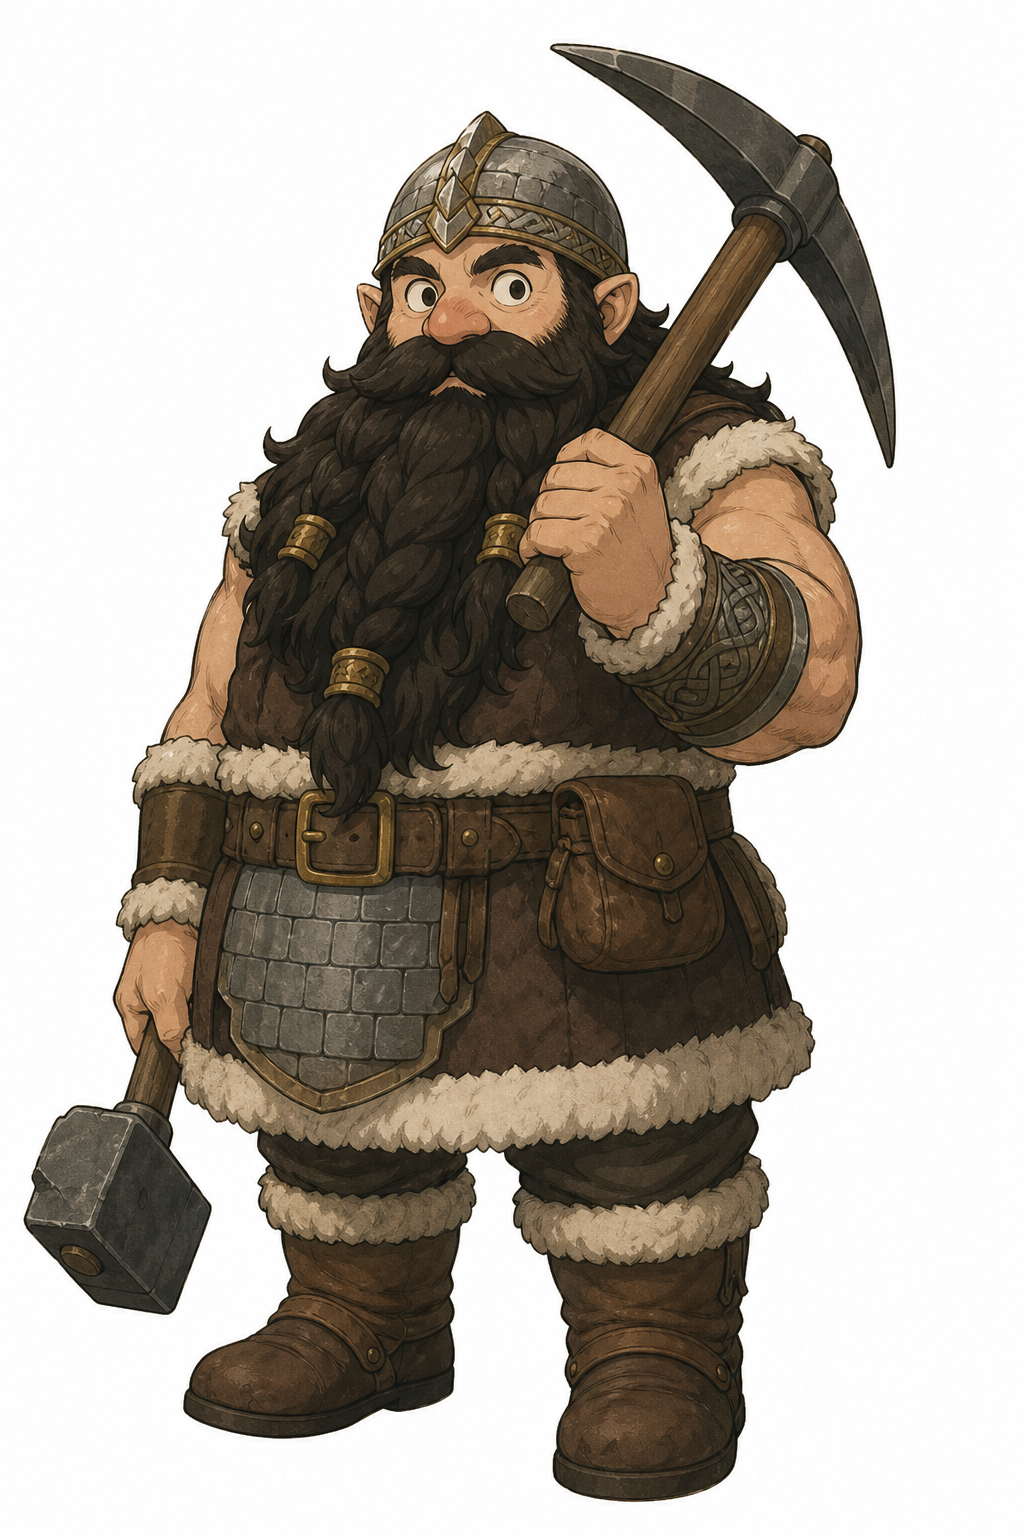

[score] consistency = 0.6915 (threshold 0.85)
[reanchor] 보강 지시문 추가:
- 투구를 완전히 제거하고 머리 부분을 노출되게 하여 얼굴과 수염의 특징이 A의 스타일과 일치하도록 유지한다.
- 망치나 모루 같은 대장장이 도구를 들고 있거나 도구가 보이도록 자세와 구도를 조정하여 직군이 명확히 보이게 한다.
- 작업복이나 가죽 앞치마를 추가해 대장장이 직군을 강조하고 벨트/포켓 등 디테일을 유지한다.
- 금속 질감(갑옷, 모루, 망치 표면)에 하이라이트를 추가하고, 불꽃/연기 효과를 적절히 배치해 작업실 분위기를 강화한다.
- 배경은 표지 삽입용으로 간소화하거나 단색으로 처리하고, A의 색감 톤과 질감을 최대한 유지한다.
- 얼굴과 머리카락이 더 선명하게 보이도록 머리카락 다듬기 및 수염 볼륨을 A와 어울리게 조정한다.
- 조명과 그림자 방향을 A와 B에서 일관되게 맞춰 시각적 흐름을 유지한다.
[score] consistency = 0.7177 (threshold 0.85)
[reanchor] 보강 지시문 추가:
- 투구를 제거한 머리 부분의 위치와 헤어 라인, 수염 볼륨을 A의 스타일에 맞춰 더 선명하고 일관되게 재현한다.
- 얼굴 특징(눈, 코, 입)의 비례와 표정 톤을 A와 같거나 비슷하게 맞춰 얼굴 인상 일치도 강화.
- 망치나 모루가 보이도록 한 손/포즈를 확정하고, 대장장이 도구가 명확히 보이도록 구도 보정.
- 작업복과 가죽 앞치마, 벨트와 포켓 디테일을 강화하되 A의 색감으로 통일감을 유지.
- 금속 질감(갑옷, 모루, 망치 표면)에 A의 하이라이트 방향으로 반사광을 추가하고 질감 차이를 명확히 한다.
- 불꽃/연기 효과를 A의 분위기에 맞춰 배치하되 과도함 없이 배색과 명도를 조절한다.
- 배경은 표지 삽입용으로 간소화하거나 단색으로 처리하고, A의 색감 톤과 질감을 최대한 유지한다.
- 조명과 그림자 방향을 A와 B에서 일관되게 맞춰 시각적 흐름을 유지한다.
[score] consistency = 0

{'prompt': '던전밥 일러스트 스타일의 판타지 풍, 드워프 남자 인물 캐릭터 하나 만들어줘. 배경은 없었으면 좋겠고, 표지 일러스트에 삽입되는 이미지처럼 만들어줘.',
 'edit_instruction': '투구를 제거하고 머리 부분이 노출되도록 수정한 뒤, 대장장이로서의 직군이 명확히 보이도록 다음을 반영한다: 망치나 모루 같은 대장장이 도구를 들고 있거나 도구가 보이도록 배치, 작업복이나 가죽 앞치마를 입혀 직군을 강조, 금속 질감과 불꽃/연기 효과를 추가해 작업실 분위기를 강화.\n- 투구를 완전히 제거하고 머리 부분을 노출되게 하여 얼굴과 수염의 특징이 A의 스타일과 일치하도록 유지한다.\n- 망치나 모루 같은 대장장이 도구를 들고 있거나 도구가 보이도록 자세와 구도를 조정하여 직군이 명확히 보이게 한다.\n- 작업복이나 가죽 앞치마를 추가해 대장장이 직군을 강조하고 벨트/포켓 등 디테일을 유지한다.\n- 금속 질감(갑옷, 모루, 망치 표면)에 하이라이트를 추가하고, 불꽃/연기 효과를 적절히 배치해 작업실 분위기를 강화한다.\n- 배경은 표지 삽입용으로 간소화하거나 단색으로 처리하고, A의 색감 톤과 질감을 최대한 유지한다.\n- 얼굴과 머리카락이 더 선명하게 보이도록 머리카락 다듬기 및 수염 볼륨을 A와 어울리게 조정한다.\n- 조명과 그림자 방향을 A와 B에서 일관되게 맞춰 시각적 흐름을 유지한다.\n- 투구를 제거한 머리 부분의 위치와 헤어 라인, 수염 볼륨을 A의 스타일에 맞춰 더 선명하고 일관되게 재현한다.\n- 얼굴 특징(눈, 코, 입)의 비례와 표정 톤을 A와 같거나 비슷하게 맞춰 얼굴 인상 일치도 강화.\n- 망치나 모루가 보이도록 한 손/포즈를 확정하고, 대장장이 도구가 명확히 보이도록 구도 보정.\n- 작업복과 가죽 앞치마, 벨트와 포켓 디테일을 강화하되 A의 색감으로 통일감을 유지.\n- 금속 질감(갑옷, 모루, 망치 표면)에 A의 하이라이트 방향으로 반사광을 추가하고 질감 차이를 명확히 한다.\n- 불꽃/연기 효과를 A의 분

In [6]:
graph.invoke({ "prompt": input("생성하고자 하는 이미지에 대해 설명해주세요.") })